In [1]:
import numpy as np
import pandas as pd
import pyfixest as pf
import matplotlib.pyplot as plt

In [2]:
DATA_PATH = "/Users/felixschulz/Library/CloudStorage/OneDrive-Personal/Dokumente/Job/UNI/Basel/Research/river-pollution-brazil/data/assembly/sensor_panel.parquet"

df = pd.read_parquet(DATA_PATH)

n_missing_year = df["year"].isna().sum()
if n_missing_year:
    print(f"Dropping {n_missing_year:,} rows with missing year")
    df = df.dropna(subset=["year"])
df["year"] = df["year"].astype(int)

n_pre_1970 = (df["year"] < 1970).sum()
if n_pre_1970:
    print(f"Dropping {n_pre_1970:,} rows with readings before 1970")
    df = df[df["year"] >= 1970]

df.shape

Dropping 553 rows with missing year
Dropping 2 rows with readings before 1970


(208057, 239)

In [3]:
# --- Variable name mapping --------------------------------------------------
# The panel stores land cover two ways (src/data/land_cover/composition.py):
# raw distance-weighted shares under lc_* (used for descriptives), and
# additive-log-ratio (alr_*) transforms against the combined natural-land
# reference (lc_forest + lc_nonforest_nat, i.e. c1+c2 -- not forest alone, so
# Cerrado/Caatinga's natural non-forest state isn't miscoded as disturbance),
# with a pseudocount before the ratio and a single inv-sqrt-distance kernel
# weight per bucket. That's the correctly-specified regressor: coefficients
# on alr_pasture etc. read as "effect of converting natural vegetation to
# pasture/etc.", consistent across biomes. lc_pasture_dw/lc_agri_dw/... in
# the spec therefore map to alr_pasture/alr_agriculture/alr_urban/alr_mining/
# alr_other for the regressions; lc_* (raw shares) is kept only for
# descriptive statistics.
#
# Climate covariates are renamed from the panel's `<var>_mean_<window>`
# naming to the spec's short names; `2t_mean_365d` is additionally renamed
# because a leading digit is not a valid formula identifier for pyfixest.
CLIMATE_RENAME = {
    "tp_mean_day": "tp_1",
    "tp_mean_7d": "tp_7",
    "sro_mean_7d": "sro_7",
    "swvl1_mean_30d": "swvl1_30",
    "swvl2_mean_90d": "swvl2_90",
    "ssro_mean_180d": "ssro_180",
    "tp_mean_365d": "tp_365",
    "pev_mean_365d": "pev_365",
    "2t_mean_365d": "t2m_365",
}
df = df.rename(columns=CLIMATE_RENAME)

LC_COLS = ["lc_pasture", "lc_agriculture", "lc_urban", "lc_mining", "lc_other"]
ALR_COLS = ["alr_pasture", "alr_agriculture", "alr_urban", "alr_mining", "alr_other"]
CLIMATE_COLS = list(CLIMATE_RENAME.values())

# The spec clusters on `basin_id`. `system_id` (a disconnected-river-system
# identifier, i.e. connected component of the flow graph -- see
# src.data.river_network.core) is the real basin unit and has been wired into
# setup/assembly_datasets.yaml as a new `river_system` source joined on
# trench_id (100% match rate against the current panel). It isn't in this
# copy of the panel yet because assembly needs to be rerun on HPC; this falls
# back to two-way clustering on station_code + year until then, and picks up
# system_id automatically once the panel is regenerated.
CLUSTER_VARS = "system_id+year" if "system_id" in df.columns else "station_code+year"

# Pasture-associated pollution: fecal indicators, nutrients, organic load,
# algal/cyanobacterial response, and physical (turbidity/solids/oxygen) signals.
PASTURE_OUTCOMES = [
    "thermotolerant_coliforms", "fecal_coliforms", "escherichia",
    "total_nitrogen", "ammoniacal_nitrogen", "total_phosphorus",
    "biochemical_oxygen_demand", "chemical_oxygen_demand",
    "chlorophyll", "cyanobacteria_density",
    "turbidity", "total_suspended_solids",
    "dissolved_oxygen",
]

# Mining-associated pollution: metals/metalloids, sulfates, conductivity,
# solids/turbidity, and (sometimes) pH/oxygen.
MINING_OUTCOMES = [
    "arsenic", "cadmium", "lead", "mercury", "manganese", "copper", "zinc",
    "aluminum", "sulfates", "electrical_conductivity",
    "total_suspended_solids", "turbidity", "ph", "dissolved_oxygen",
]

OUTCOME_GROUPS = {"pasture": PASTURE_OUTCOMES, "mining": MINING_OUTCOMES}
ALL_OUTCOMES = sorted(set(PASTURE_OUTCOMES) | set(MINING_OUTCOMES))

## 1. Descriptive statistics

In [4]:
# Panel coverage
print(f"Observations: {len(df):,}")
print(f"Stations: {df['station_code'].nunique():,}")
print(f"Years: {df['year'].min()}–{df['year'].max()}")
print(f"Biomes: {sorted(df['biome'].dropna().unique().tolist())}")

df.groupby("biome").agg(
    n_obs=("station_code", "size"),
    n_stations=("station_code", "nunique"),
    year_min=("year", "min"),
    year_max=("year", "max"),
)

Observations: 208,057
Stations: 6,426
Years: 1970–2026
Biomes: ['Amazônia', 'Caatinga', 'Cerrado', 'Mata Atlântica', 'Pampa', 'Pantanal']


,n_obs,n_stations,year_min,year_max
biome,,,,
Amazônia,17657,676,1975,2026
Caatinga,17277,957,1976,2025
Cerrado,47892,1608,1970,2025
Mata Atlântica,116602,2904,1971,2025
Pampa,4647,199,1976,2024
Pantanal,3982,82,1979,2024


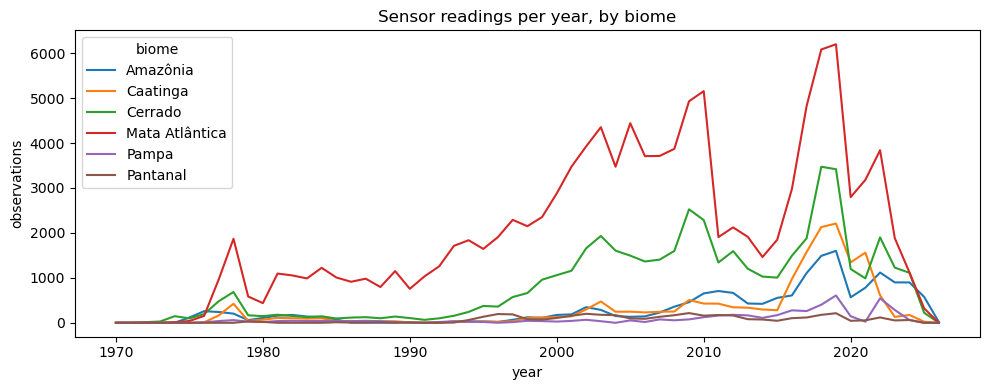

In [5]:
# Observations per year, by biome
obs_by_year_biome = df.groupby(["year", "biome"]).size().unstack("biome").fillna(0)

fig, ax = plt.subplots(figsize=(10, 4))
obs_by_year_biome.plot(ax=ax)
ax.set_ylabel("observations")
ax.set_title("Sensor readings per year, by biome")
plt.tight_layout()
plt.show()

In [6]:
# Outcome variables: coverage + distribution
outcome_coverage = df[ALL_OUTCOMES].notna().sum().rename("n_obs").to_frame()
outcome_coverage["missing_share"] = 1 - outcome_coverage["n_obs"] / len(df)
outcome_coverage.sort_values("n_obs", ascending=False)

,n_obs,missing_share
ph,193425,0.070327
dissolved_oxygen,184855,0.111518
turbidity,166434,0.200056
electrical_conductivity,118699,0.429488
biochemical_oxygen_demand,115319,0.445734
ammoniacal_nitrogen,100835,0.515349
total_phosphorus,96561,0.535892
chemical_oxygen_demand,75398,0.637609
fecal_coliforms,74193,0.643401
total_nitrogen,68235,0.672037


In [7]:
df[ALL_OUTCOMES].describe().T

,count,mean,std,min,25%,50%,75%,max
aluminum,11910.0,1.662353,3.729974e+01,0.0,0.100000,0.1700,0.550000,2.500000e+03
ammoniacal_nitrogen,100835.0,1.025159,1.125826e+01,0.0,0.040000,0.1000,0.400000,2.709000e+03
arsenic,12029.0,0.013829,1.268770e-01,0.0,0.000500,0.0011,0.010000,6.300000e+00
biochemical_oxygen_demand,115319.0,7.137292,1.849290e+02,0.0,2.000000,2.0000,4.000000,4.664000e+04
cadmium,31300.0,0.008694,2.624257e-01,0.0,0.000500,0.0010,0.002000,4.000000e+01
chemical_oxygen_demand,75398.0,39.325098,5.381119e+02,0.0,8.000000,17.0000,35.000000,1.135200e+05
chlorophyll,26622.0,13.522408,1.054801e+02,0.0,0.801000,1.7600,5.907500,9.718800e+03
copper,26084.0,0.020681,3.384707e-01,0.0,0.004000,0.0076,0.010000,5.100000e+01
cyanobacteria_density,5133.0,111582.773773,4.534562e+05,0.0,102.050003,11434.5000,84596.000000,2.592534e+07
dissolved_oxygen,184855.0,6.623311,2.263270e+00,0.0,5.700000,7.0000,7.920000,4.000000e+01


In [8]:
# Land-cover (raw shares + additive-log-ratio regressors) and climate covariates
df[LC_COLS + ALR_COLS + CLIMATE_COLS].describe().T

,count,mean,std,min,25%,50%,75%,max
lc_pasture,183534.0,2.668072e-01,0.223126,0.000000e+00,6.822560e-02,2.184496e-01,4.307114e-01,9.800919e-01
lc_agriculture,183534.0,1.146938e-01,0.179426,0.000000e+00,7.908568e-04,2.111775e-02,1.545645e-01,9.575929e-01
lc_urban,183534.0,2.994135e-02,0.086523,0.000000e+00,7.427985e-04,3.893315e-03,1.706989e-02,1.000000e+00
lc_mining,183534.0,1.200097e-03,0.007703,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,3.334268e-01
lc_other,183534.0,1.573393e-03,0.003545,0.000000e+00,1.930198e-04,6.274470e-04,1.612547e-03,1.228068e-01
alr_pasture,183534.0,-1.046313e+00,2.345594,-9.210440e+00,-1.923356e+00,-5.202960e-01,5.804214e-01,6.869574e+00
alr_agriculture,183534.0,-3.362425e+00,3.369694,-9.210440e+00,-6.181625e+00,-2.955372e+00,-5.728169e-01,3.920805e+00
alr_urban,183534.0,-4.489847e+00,2.631192,-9.210440e+00,-6.350349e+00,-4.395522e+00,-2.605706e+00,9.210440e+00
alr_mining,183534.0,-7.560454e+00,1.466448,-9.210440e+00,-8.662482e+00,-7.871283e+00,-6.988968e+00,0.000000e+00
alr_other,183534.0,-6.137057e+00,1.494488,-9.210440e+00,-7.129816e+00,-6.056369e+00,-5.114996e+00,0.000000e+00


## 2. Regressions — Spec 1: two-way FE baseline (fast, national)

```
log(pollutant) ~
    alr_pasture + alr_agriculture + alr_urban + alr_mining + alr_other +
    alr_pasture:sro_7 + alr_agriculture:sro_7 +
    tp_1 + tp_7 + swvl1_30 + swvl2_90 + ssro_180 + tp_365 + pev_365 + t2m_365 |
    station_code + biome^year
```

Land-cover regressors are the additive-log-ratio (`alr_*`) transforms against
the combined natural-land reference, not raw `lc_*` shares — see the note
above `ALR_COLS`. This also sidesteps the raw shares' compositional
(sum-to-less-than-one, boundary-at-zero) structure.

`feols(..., vcov={"CRV1": CLUSTER_VARS})`. Two-way clustering is on
`system_id + year` (river-system = basin identifier, see the note above
`CLUSTER_VARS`) once the panel has been rebuilt with it, falling back to
`station_code + year` otherwise. `biome^year` lets national shocks (El Niño,
commodity cycles) hit biomes differently.

Run once per outcome in each pollution-source group (pasture, mining),
matched to the variables available in the panel.

In [9]:
RHS = (
    "alr_pasture + alr_agriculture + alr_urban + alr_mining + alr_other"
    " + alr_pasture:sro_7 + alr_agriculture:sro_7"
    " + tp_1 + tp_7 + swvl1_30 + swvl2_90 + ssro_180 + tp_365 + pev_365 + t2m_365"
)
FE = "station_code + biome^year"

results = {}
for group, outcomes in OUTCOME_GROUPS.items():
    results[group] = {}
    for outcome in outcomes:
        log_col = f"log_{outcome}"
        if log_col not in df.columns:
            df[log_col] = np.log(df[outcome].where(df[outcome] > 0))

        fml = f"{log_col} ~ {RHS} | {FE}"
        try:
            fit = pf.feols(fml, data=df, vcov={"CRV1": CLUSTER_VARS})
        except Exception as exc:
            print(f"[{group}/{outcome}] failed: {exc}")
            continue
        results[group][outcome] = fit

{group: list(fits.keys()) for group, fits in results.items()}

/Users/felixschulz/miniforge3/envs/311/lib/python3.11/site-packages/pyfixest/estimation/formula/model_matrix.py:149: UserWarning: 159 singleton fixed effect(s) dropped from the model.
  warnings.warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
/Users/felixschulz/miniforge3/envs/311/lib/python3.11/site-packages/pyfixest/estimation/formula/model_matrix.py:149: UserWarning: 105 singleton fixed effect(s) dropped from the model.
  warnings.warn(
/Users/felixschulz/miniforge3/envs/311/lib/python3.11/site-packages/pyfixest/estimation/formula/model_matrix.py:149: UserWarning: 174 singleton fixed effect(s) dropped from the model.
  warnings.warn(
/Users/felixschulz/miniforge3/envs/311/lib/python3.11/site-packages/pyfixest/estimation/models/_result_accessor_mixin.py:85: RuntimeWarning: invalid value encountered in sqrt
  self._se = np.sqrt(np.diagonal(self._vcov))
/Users/felixschulz/miniforge3/envs/311/lib/python3.11/site-packages/pyfixest/es

{'pasture': ['thermotolerant_coliforms',
  'fecal_coliforms',
  'escherichia',
  'total_nitrogen',
  'ammoniacal_nitrogen',
  'total_phosphorus',
  'biochemical_oxygen_demand',
  'chemical_oxygen_demand',
  'chlorophyll',
  'cyanobacteria_density',
  'turbidity',
  'total_suspended_solids',
  'dissolved_oxygen'],
 'mining': ['arsenic',
  'cadmium',
  'lead',
  'mercury',
  'manganese',
  'copper',
  'zinc',
  'aluminum',
  'sulfates',
  'electrical_conductivity',
  'total_suspended_solids',
  'turbidity',
  'ph',
  'dissolved_oxygen']}

### Pasture-linked outcomes

In [10]:
pf.etable(list(results["pasture"].values()))

/Users/felixschulz/miniforge3/envs/311/lib/python3.11/site-packages/pyfixest/estimation/models/_result_accessor_mixin.py:85: RuntimeWarning: invalid value encountered in sqrt
  self._se = np.sqrt(np.diagonal(self._vcov))
/Users/felixschulz/miniforge3/envs/311/lib/python3.11/site-packages/pyfixest/estimation/models/_result_accessor_mixin.py:85: RuntimeWarning: invalid value encountered in sqrt
  self._se = np.sqrt(np.diagonal(self._vcov))


GT(_tbl_data=   __index_level_0__        __index_level_1__                          0  \
0               coef              alr_pasture         0.184 <br> (1.272)   
1               coef          alr_agriculture         3.748 <br> (0.959)   
2               coef                alr_urban        -0.611 <br> (0.329)   
3               coef               alr_mining         0.403 <br> (0.214)   
4               coef                alr_other         -0.039 <br> (0.12)   
5               coef                     tp_1   0.000002 <br> (0.000003)   
6               coef                     tp_7   0.000005 <br> (0.000004)   
7               coef                 swvl1_30         3.510 <br> (1.226)   
8               coef                 swvl2_90        -2.374 <br> (1.653)   
9               coef                 ssro_180  -0.000002 <br> (0.000006)   
10              coef                   tp_365  -0.000028 <br> (0.000023)   
11              coef                  pev_365   0.000052 <br> (0.000061)   
12              coef                  t2m_365         0.138 <br> (0.234)   
13              coef      alr_pasture × sro_7         -0 <br> (0.000001)   
14              coef  alr_agriculture × sro_7  -0.000002 <br> (0.000001)   
15                fe               biome^year                          x   
16                fe            station_code                           x   
17             stats             Observations                     11,505   
18             stats                       R²                      0.532   

                            1                         2  \
0         -3.125 <br> (0.467)           -1.948 <br> (-)   
1          2.828 <br> (0.379)        1.247 <br> (0.476)   
2          0.416 <br> (0.084)        0.459 <br> (0.251)   
3          0.908 <br> (0.193)       -0.013 <br> (0.055)   
4          0.197 <br> (0.117)        0.013 <br> (0.068)   
5           0.000001 <br> (0)  0.000001 <br> (0.000001)   
6           0.000009 <br> (0)  0.000003 <br> (0.000002)   
7          3.949 <br> (0.576)        5.065 <br> (0.997)   
8           -0.5 <br> (0.848)       -1.396 <br> (1.029)   
9   -0.000001 <br> (0.000001)  0.000004 <br> (0.000001)   
10  -0.000006 <br> (0.000016)  0.000007 <br> (0.000007)   
11  -0.000014 <br> (0.000014)  -0.00002 <br> (0.000008)   
12         0.203 <br> (0.068)        0.006 <br> (0.082)   
13          0.000002 <br> (0)         0.000001 <br> (-)   
14         -0.000002 <br> (0)        -0.000001 <br> (0)   
15                          x                         x   
16                          x                         x   
17                     62,131                    19,570   
18                      0.654                     0.829   

                            3                          4  \
0         -0.595 <br> (0.614)        -1.021 <br> (0.605)   
1          0.347 <br> (0.259)          0.709 <br> (0.37)   
2          0.033 <br> (0.066)         0.028 <br> (0.051)   
3          0.075 <br> (0.043)         0.131 <br> (0.038)   
4         -0.009 <br> (0.013)        -0.074 <br> (0.033)   
5          -0 <br> (0.000001)          0.000001 <br> (0)   
6           0 <br> (0.000001)  -0.000002 <br> (0.000001)   
7          0.844 <br> (0.202)         -0.27 <br> (0.288)   
8         -0.676 <br> (0.377)        -1.495 <br> (0.263)   
9   -0.000001 <br> (0.000002)  -0.000002 <br> (0.000001)   
10  -0.000012 <br> (0.000004)  -0.000006 <br> (0.000005)   
11   0.000008 <br> (0.000004)  -0.000003 <br> (0.000008)   
12          0.05 <br> (0.037)         -0.023 <br> (0.03)   
13                 0 <br> (0)          0.000001 <br> (0)   
14                -0 <br> (0)                -0 <br> (0)   
15                          x                          x   
16                          x                          x   
17                     32,290                     79,927   
18                      0.705                      0.727   

                            5                          6  \
0          -1.035 <br> (

### Mining-linked outcomes

In [11]:
pf.etable(list(results["mining"].values()))

/Users/felixschulz/miniforge3/envs/311/lib/python3.11/site-packages/pyfixest/estimation/models/_result_accessor_mixin.py:85: RuntimeWarning: invalid value encountered in sqrt
  self._se = np.sqrt(np.diagonal(self._vcov))
/Users/felixschulz/miniforge3/envs/311/lib/python3.11/site-packages/pyfixest/estimation/models/_result_accessor_mixin.py:85: RuntimeWarning: invalid value encountered in sqrt
  self._se = np.sqrt(np.diagonal(self._vcov))


GT(_tbl_data=   __index_level_0__        __index_level_1__                          0  \
0               coef              alr_pasture        -2.086 <br> (1.060)   
1               coef          alr_agriculture         0.704 <br> (0.765)   
2               coef                alr_urban        -0.028 <br> (0.253)   
3               coef               alr_mining         -0.35 <br> (0.116)   
4               coef                alr_other          0.062 <br> (0.06)   
5               coef                     tp_1                -0 <br> (0)   
6               coef                     tp_7   0.000003 <br> (0.000003)   
7               coef                 swvl1_30         0.142 <br> (0.286)   
8               coef                 swvl2_90         1.570 <br> (0.852)   
9               coef                 ssro_180  -0.000006 <br> (0.000002)   
10              coef                   tp_365  -0.000004 <br> (0.000018)   
11              coef                  pev_365  -0.000015 <br> (0.000018)   
12              coef                  t2m_365          0.183 <br> (0.15)   
13              coef      alr_pasture × sro_7   0.000001 <br> (0.000001)   
14              coef  alr_agriculture × sro_7                -0 <br> (0)   
15                fe               biome^year                          x   
16                fe            station_code                           x   
17             stats             Observations                     10,163   
18             stats                       R²                      0.836   

                            1                          2  \
0         -0.682 <br> (0.388)        -0.874 <br> (0.559)   
1          0.468 <br> (0.313)         0.744 <br> (0.355)   
2          -0.11 <br> (0.075)        -0.088 <br> (0.057)   
3         -0.007 <br> (0.017)         0.051 <br> (0.048)   
4           0.09 <br> (0.055)         0.046 <br> (0.021)   
5          -0.000001 <br> (0)         -0 <br> (0.000001)   
6          -0 <br> (0.000001)         -0 <br> (0.000001)   
7          0.052 <br> (0.248)         0.738 <br> (0.248)   
8          0.334 <br> (0.388)         0.925 <br> (0.454)   
9    0.000001 <br> (0.000002)  -0.000001 <br> (0.000002)   
10  -0.000008 <br> (0.000015)  -0.000017 <br> (0.000014)   
11  -0.000005 <br> (0.000011)   0.000002 <br> (0.000015)   
12         0.109 <br> (0.074)         0.152 <br> (0.071)   
13          0.000001 <br> (0)          0.000001 <br> (0)   
14                -0 <br> (0)                -0 <br> (0)   
15                          x                          x   
16                          x                          x   
17                     28,144                     28,701   
18                      0.667                      0.738   

                            3                          4  \
0          0.109 <br> (0.844)        -1.858 <br> (0.434)   
1          0.065 <br> (0.305)         1.717 <br> (0.631)   
2         -0.191 <br> (0.077)        -0.177 <br> (0.234)   
3          0.175 <br> (0.134)         0.163 <br> (0.093)   
4          0.107 <br> (0.044)         0.011 <br> (0.047)   
5                  0 <br> (0)   0.000002 <br> (0.000001)   
6           0 <br> (0.000001)   0.000004 <br> (0.000002)   
7          0.321 <br> (0.338)         1.902 <br> (0.598)   
8          0.164 <br> (0.446)         1.672 <br> (0.469)   
9   -0.000005 <br> (0.000002)  -0.000017 <br> (0.000004)   
10   0.000003 <br> (0.000014)   0.000012 <br> (0.000014)   
11   -0.000014 <br> (0.00001)  -0.000057 <br> (0.000013)   
12         -0.21 <br> (0.085)         0.371 <br> (0.112)   
13                 0 <br> (0)          0.000001 <br> (0)   
14                -0 <br> (0)         -0.000001 <br> (0)   
15                          x                          x   
16                          x                          x   
17                     26,305                     14,615   
18                      0.939                      0.687   

                            5                          6  \
0   